Code for only running autoencoder 
#### changelog 
+ v2- successfully runnig N iterations across all combinations
+ v3- adding WT CLNZ and streamlinecode. created N indepdenent bootstrap run code to evaluate staiblity of results. packaged resample function

In [1]:
!ls 


autoencoder_cloud_requirements.txt		  external_functions.py
autoencoder_training_cloud_plot_results_v1.ipynb  LICENSE
autoencoder_training_cloud_run_v1.ipynb		  paper_plot.mplstyle
autoencoder_training.ipynb			  README.md
ax_modifier_functions_cloud.py			  sample_data
CLAUDE.md					  service_account_key.json
data						  sns_plotting_config.py
desktop.ini


In [2]:
# %load_ext autoreload
# %autoreload 2
%pip install -r autoencoder_cloud_requirements.txt
%matplotlib inline
import sys
import os
import logging #to suppress pytorch GPU output etc
import warnings
#supress specific future warnings and automatic lighitning outputs
logging.getLogger("lightning.pytorch.utilities.rank_zero").setLevel(logging.FATAL)
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.WARNING)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore",r".*does not have many workers which may be a bottleneck.*")
warnings.filterwarnings("ignore",".*GPU available.*",category=UserWarning) # option 2: just filter out the GPU‐warning
#run import modules for analysis 
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import itertools
from tqdm import tqdm
import datetime
import pickle
import sklearn
from sklearn.metrics import davies_bouldin_score
print(f"matplotlib version: {matplotlib.__version__},sns version: {sns.__version__},pandas ver: {pd.__version__}")
#torch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import TensorDataset, DataLoader
import tensorboard
from functools import partial
from joblib import Parallel, delayed 
#custom loads
from external_functions import *
from sns_plotting_config import *
from ax_modifier_functions_cloud import *
plt.style.use('paper_plot.mplstyle')
#colab kernel fixes 
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Available on Colab
plt.rcParams['font.family'] = 'sans-serif'
## elsevier fig sizes https://www.elsevier.com/about/policies-and-standards/author/artwork-and-media-instructions/artwork-sizing

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
matplotlib version: 3.7.0,sns version: 0.12.1,pandas ver: 1.5.2


<Figure size 640x480 with 0 Axes>

In [3]:
# # Define the relative path to the src directory
# module_path = r'G:\My Drive\Colab notebooks\Function .py Storage\plot_posthoc_test\src\plot_posthoc_test'
# function_dir =  os.path.join(r'G:\\My Drive\\Colab notebooks\\', 'Function .py Storage')
# print(function_dir)
# if module_path not in sys.path:
#     sys.path.append(module_path)
# if function_dir not in sys.path:
#     sys.path.append(function_dir)
# # Import functions and classes from plot_stat_annotate
# from plot_stat_annotate import *



In [4]:
print(os.getcwd())

/content


## Process Data 


#### Create dataset object for resampling in bootstrapabs

In [5]:
folder_loc = '/Run Outputs/'
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
print(f"date tag: {date_tag}")
folder_name =folder_loc+  f"figure_5_postSVM_decoding_accuracy_and_PCA_plots_"+ date_tag + "/"

date tag: 01_Jan_2026


In [6]:
# new folder structure:
# outputs/                     # For trained models and results
# │   ├── models/                  # Trained model checkpoints
# │   ├── figures/                 # Generated figures
# │   └── logs/                    # Lightning logs
    
data_folder = os.getcwd() +"/data/"
output_folder = os.getcwd() +"/output/"
model_results_folder = output_folder + "/model_results/"
current_run_output = model_results_folder + f"{date_tag}\\"
all_figure_output_folder = output_folder +"/figures/"
fig_output = all_figure_output_folder + f"{date_tag}\\"
#make folders 
make_folder(output_folder)
make_folder(all_figure_output_folder)
make_folder(fig_output)
make_folder(model_results_folder)
make_folder(current_run_output)

Created folder: /content/output/
Created folder: /content/output//figures/
Created folder: /content/output//figures/01_Jan_2026\
Created folder: /content/output//model_results/
Created folder: /content/output//model_results/01_Jan_2026\


'/content/output//model_results/01_Jan_2026\\'

In [7]:
new_trial_df_filename = r"python-made_trial_timeseries_raster_2025-12-21 12.parquet"

In [8]:
#declare loc/names of files to read
load_dataset = True
save_norm_trial_dataset = True
# trial_df_filename = data_folder +  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_df_filename = data_folder +  new_trial_df_filename
if load_dataset:
    print(f"loading_dataset")
    trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm.tail()

loading_dataset


,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_RS_Correct,Late_RS,any_enrichment,enriched_in_phase,max_trial_val,mean_rate,active_in_trial,normalization,data_type,date saved
3947,38,cell_95,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-95,3,...,0.0,0.0,1.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3948,38,cell_96,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-96,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3949,38,cell_97,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-97,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3950,38,cell_98,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-98,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3951,38,cell_99,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-99,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12


In [9]:
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ") #in external_functions.py
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = 'neuron_id', subj_name_col = 'subject_name')#.rename({'neuron_id': "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')['neuron_id'].nunique()
print(n_total_units)
print(n_total_units.sum())
subject_stage_info_df.tail()

geno_day
Het CLNZ         840
Het VEH          851
Het postCLNZ     914
WT CLNZ          985
WT VEH          1034
Name: neuron_id, dtype: int64
4624


,subject_name,geno_day,task_phase_vec,neuron_id,num_enriched_units,num_units,trial_num,count_of_trials,over_5
196,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-100, 9_3_HET_RS3-129, 9_3_HET_RS3...",23,171,"[3, 5]",2,"[False, False]"
197,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-124, 9_3_HET_RS3-129, 9_3_HET_RS3...",10,171,"[17, 19, 21]",3,"[True, True, True]"
198,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-128, 9_3_HET_RS3-138, 9_3_HET_RS3...",12,171,"[18, 20]",2,"[True, True]"
199,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-129, 9_3_HET_RS3-138, 9_3_HET_RS3...",16,171,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-130, 9_3_HET_RS3-169, 9_3_HET_RS3...",4,171,"[34, 35, 36, 38]",4,"[True, True, True, True]"


#### save class matrix store for loading later

In [10]:
# ## helper functions imported from phase_enrich_timeseries_decode.py module
def get_dataset_names_in_geno(dataset_name_by_geno_day,
                              geno_day,
                              subject_name_col = 'subject_name'):
    datasets_in_geno = dataset_name_by_geno_day.loc[dataset_name_by_geno_day.geno_day == geno_day,subject_name_col].values[0] #get name of datasets in current geno_day setup
    return datasets_in_geno

 ## imported subfunc for cuDF speedup
def get_tseries_of_dataset(timeseries_df, 
                           dataset_name, 
                           subject_name_col = 'subject_name'):
    #get time-series that are occurign in phase of interest
    dataset_df_slice = timeseries_df.loc[timeseries_df[subject_name_col] == dataset_name]
    return dataset_df_slice

def get_tseries_in_phase(timeseries_df, phase_name):
    phase_dataset_df_slice = timeseries_df.loc[timeseries_df.task_phase_vec == phase_name]
    return phase_dataset_df_slice

def get_tseries_phase_enrich_cells(tseries_df, unit_ID_col, enrichment_ID_df, dataset_name, e_phase_name):
    enrich_in_phase_unit_IDs = get_dataset_units_enrich_in_phase(enrichment_ID_df, unit_ID_col, dataset_name, e_phase_name) #get unit IDs that are enriched in phase of interest
    enrich_in_phase_dataset_df = tseries_df.loc[tseries_df[unit_ID_col].isin(enrich_in_phase_unit_IDs)]#get unit time-series only if they enriched in phase of interest
    return enrich_in_phase_dataset_df, enrich_in_phase_unit_IDs

def get_dataset_units_enrich_in_phase(enrich_unit_by_name_phase_df,
                                       unit_ID_col,
                                         dataset_name,
                                           stage_of_interest,
                                           subject_name_col = 'subject_name'):
    name_mask = enrich_unit_by_name_phase_df[subject_name_col] == dataset_name
    phase_mask = enrich_unit_by_name_phase_df.task_phase_vec == stage_of_interest
    enrich_in_phase_unit_IDs =enrich_unit_by_name_phase_df.loc[phase_mask&name_mask, unit_ID_col].values[0]
    return enrich_in_phase_unit_IDs

def horzcat_all_trials(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col]
    grouped = {
        trial: group.set_index(unit_col_name)[tseries_cols]
        for trial, group in timeseries_df.groupby('trial_num', sort=False)
    }
    return pd.concat(grouped.values(), axis=1)

In [11]:
def horzcat_all_trials_original(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col] 
    trial_slice_storage = []
    for trial in timeseries_df.trial_num.unique():
        trial_slice = timeseries_df.loc[timeseries_df.trial_num == trial].set_index(unit_col_name)
        trial_slice_storage.append(trial_slice.loc[:,tseries_cols])
    return pd.concat(trial_slice_storage, axis=1)

# Test
result_orig = horzcat_all_trials_original(trial_tseries_df_norm, numeric_col,'neuron_id')
result_opt = horzcat_all_trials(trial_tseries_df_norm, numeric_col,'neuron_id')

print("Identical:", result_orig.equals(result_opt))
print("Shape match:", result_orig.shape == result_opt.shape)
print("Columns match:", list(result_orig.columns) == list(result_opt.columns))
print("Index match:", list(result_orig.index) == list(result_opt.index))

Identical: True
Shape match: True
Columns match: True
Index match: True


In [12]:
def make_dataset_matrix_store_only(phase_names, 
                                   trial_tseries_df_norm,
                                   unit_ID_col,
                                   enrich_unit_ID_by_name_df,
                                    numeric_col,
                                    trial_list_by_dataset,
                                   dataset_name_by_geno_day,
                                   phase_enrichment_by_subj,
                                     subject_name_col = 'subject_name'):
    """TO- create a dict where key1 = stage the pseudopop is enriched in, key 2 = stage to look for activity of, and key 3- genotype of current datset"""
    ppop_data,stage_geno_tseries = dict(), dict()
    iter_ct = 0
    for e_phase in phase_names:
        ppop_data[e_phase],stage_geno_tseries[e_phase] = {},{}
        print("Get enrich in ",e_phase, "act. in ", phase_names)

        for act_phase in phase_names:
            datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
            ppop_data[e_phase][act_phase],stage_geno_tseries[e_phase][act_phase]= {},{}

            for geno_day in dataset_name_by_geno_day.geno_day.unique():
                datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day)
                geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
                current_ppop_draw = dict()
                
                for dataset in geno_dataset_w_act:
                    iter_ct = iter_ct+1
                    #check if > 0 cells are enriched in stage
                    if phase_enrichment_by_subj.set_index(subject_name_col).loc[dataset, e_phase] > 0:
                        phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset), act_phase)
                        e_in_phase_data_df,e_in_stage_ID =get_tseries_phase_enrich_cells(phase_dataset_df, unit_ID_col,
                                                                                         enrich_unit_ID_by_name_df, dataset, e_phase)
                        current_ppop_draw[dataset] =  horzcat_all_trials(e_in_phase_data_df,numeric_col, unit_ID_col)
                ppop_data[e_phase][act_phase][geno_day] =current_ppop_draw
    return ppop_data

In [13]:
from google.oauth2 import service_account
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

lightning_autoencoder_googleID = '1D6Vg0uPWJD4hHEaS4nDtFPNBoWZY2ovN'
# ============ SETUP (run once per session) ============
SCOPES = ['https://www.googleapis.com/auth/drive']
SERVICE_ACCOUNT_FILE = 'service_account_key.json'
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
drive_service = build('drive', 'v3', credentials=creds)
drive_service

In [14]:

def save_to_drive(local_path, drive_filename, folder_id=None):
    """Upload file to Google Drive. Optionally specify a folder ID."""
    if not os.path.exists(local_path):
        print(f"Warning: {local_path} does not exist, skipping upload")
        return None
    metadata = {'name': drive_filename}
    if folder_id:
        metadata['parents'] = [folder_id]
    media = MediaFileUpload(local_path)
    file = drive_service.files().create(body=metadata,
                                        media_body=media,
                                        fields='id',
                                        supportsAllDrives=True).execute()
    # Transfer ownership to your personal account
    drive_service.permissions().create(
        fileId=file_id,
        transferOwnership=True,
        body={'type': 'user', 'role': 'owner',
               'emailAddress': "13carlosj@gmail.com"}).execute()
    print(f"Saved to Drive: {drive_filename}")
    file_id = file.get('id')
    return 

def create_drive_folder(folder_name, parent_id=None):
    metadata = {
        'name': folder_name,
        'mimeType': 'application/vnd.google-apps.folder'
    }
    if parent_id:
        metadata['parents'] = [parent_id]
    folder = drive_service.files().create(body=metadata, fields='id').execute()
    return folder.get('id')

In [15]:
from google.cloud import storage

client = storage.Client.from_service_account_json('service_account_key.json')
bucket = client.bucket('colab_autoencoder_output')

def save_to_gcs(local_path, blob_name):
    blob = bucket.blob(blob_name)
    blob.upload_from_filename(local_path)
    print(f"Uploaded: gs://colab_autoencoder_output/{blob_name}")

# Test it
save_to_gcs('/content/README.md', 'README.md')

Uploaded: gs://colab_autoencoder_output/README.md


In [16]:
local_colab_folder = os.getcwd() + "/class_matrix_results/"
#make folders 
make_folder(local_colab_folder)

Created folder: /content/class_matrix_results/


'/content/class_matrix_results/'

In [17]:
# save store class_matrix_store
class_matrix_save_file =  f"pseudopop_ensemble_activity_dict_{date_tag}.pickle"
load_filename = data_folder + f"pseudopopulation_ensemble_activity_store_20_Jun_2025.pickle"

#set options
make_class_matrix = True
save_class_matrix = True
write_to_GCS = True
neuron_ID_col = 'neuron_id'
#set loop
if make_class_matrix: ##create class matrix store
    #extract enrichment to see what subjects had 0 enriched cells 
    neuron_enrichment =  trial_tseries_df_norm.groupby(['subject_name', 'geno_day', 'neuron_id'])[stage_names].mean().reset_index()
    phase_enrichment_by_subj = neuron_enrichment[list(stage_names) + ['subject_name', 'geno_day']].groupby(by = ['subject_name', 'geno_day']).sum().reset_index()
    
    #filter by subjects with > 1 trial in a given stage 
    trial_list_by_dataset= subject_stage_info_df.loc[:,['subject_name', 
                                                        'geno_day', 'task_phase_vec', 'trial_num', 'count_of_trials']]
    trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]##important- threshold to take datasets with >1 trials per section (to have enough variety in neural activity)
    enrich_unit_ID_by_name_df = subject_stage_info_df.loc[:,['subject_name', 'geno_day', 'task_phase_vec', neuron_ID_col]]
    dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')['subject_name'].unique().reset_index()
    
    #use premade information to create new matrix
    class_matrix_store = make_dataset_matrix_store_only(stage_names,
                                                        trial_tseries_df_norm,
                                                        unit_ID_col = neuron_ID_col,
                                                        enrich_unit_ID_by_name_df = enrich_unit_ID_by_name_df, 
                                                        numeric_col = numeric_col,
                                                        trial_list_by_dataset = trial_list_by_dataset,
                                                        dataset_name_by_geno_day = dataset_name_by_geno_day,
                                                        phase_enrichment_by_subj = phase_enrichment_by_subj)
    if save_class_matrix:
        print(f"Saving {class_matrix_save_file}")
        with open(local_colab_folder + class_matrix_save_file, 'wb') as handle:
            pickle.dump(class_matrix_store, handle, protocol=pickle.HIGHEST_PROTOCOL)
            if write_to_GCS:
                print(f"Writing to CGS: {class_matrix_save_file}")
                save_to_gcs(local_colab_folder + class_matrix_save_file, local_colab_folder + class_matrix_save_file)
else: #if you don't make or save one, you load one 
    print(f" loading file: {load_filename}")
    with open(load_filename, 'rb') as handle:
        class_matrix_store = pickle.load(handle)

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Saving pseudopop_ensemble_activity_dict_01_Jan_2026.pickle
Writing to CGS: pseudopop_ensemble_activity_dict_01_Jan_2026.pickle
Uploaded: gs://colab_autoencoder_output//content/class_

## Test Pytorch Lightning Autoencoder function on sample data 

#### Define pytorch lightining functions

In [18]:
## separate into function 
def return_train_test_tensorDataset(input_data, input_labels:np.array, shuffle:bool = True, test_on_train:bool = True):
    '''TO- given numpy matrices, and optional shuffle, return 2 pytorch test and train datasets in tensor format'''
    #moved from outside func to inside
    input_data = input_data.values.T #.T.values of concat matrix is to reshape mat into what scikit wants from you
    #get indices
    assert input_data.shape[0] > 0
    rng = np.random.default_rng()
    n_samples = input_data.shape[0]
    input_data_index =np.arange(0,n_samples) 
    permuted_index = rng.permutation(input_data_index)

    if test_on_train:
        if shuffle:
            train_index = permuted_index
            test_index = permuted_index
        else: #non shuffle, test set = train set
            train_index = input_data_index
            test_index = train_index
    else: #if test not == train
        if shuffle:
            train_index = permuted_index[0:n_samples//2]
            test_index = permuted_index[n_samples//2:n_samples]
        else:
            train_index = input_data_index[0:n_samples//2]
            test_index =  input_data_index[n_samples//2:n_samples]
        
    ##extract data of interest 
    train_data= torch.tensor(input_data[train_index,:], dtype=torch.float32)
    train_labels= torch.tensor(input_labels[train_index], dtype=torch.float32)
    
    test_data = torch.tensor(input_data[test_index,:], dtype=torch.float32)
    test_labels = torch.tensor(input_labels[test_index], dtype=torch.float32)
    ## consolidate into TEnsorDataset objects
    train_dataset = TensorDataset(train_data, train_labels)
    test_dataset = TensorDataset(test_data, test_labels)
    
    return train_dataset, test_dataset

In [19]:
weight_decay = 1e-2
class dropout_net(nn.Module):
    def __init__(self, layer_1_input=50, bottleneck_input = 9, bottleneck_size = 2,dropout= 0):
        super().__init__()
        ### Using a bottleneck latent dimension of 2
        self.encoder = nn.Sequential(
            nn.Linear(layer_1_input,bottleneck_input),nn.Mish(),nn.Dropout(dropout),nn.Linear(bottleneck_input, bottleneck_size)) #from 250 node layer to 3D bottle neck/ latent space 
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size,bottleneck_input),nn.Mish(),nn.Linear(bottleneck_input, layer_1_input))

    def forward(self, x):      
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# define the LightningModule
class LitAutoEncoder(L.LightningModule):
    def __init__(self, dropout_net, **model_kwargs):#load/import  model 
        super().__init__()
        self.save_hyperparameters()# save hyperparameters to self.hparams
        self.model = dropout_net(**model_kwargs)# instantiate your model
        
    def configure_optimizers(self):
        #NEW using  weight decay baked into AdamW
        optimizer = optim.AdamW(self.parameters(),weight_decay = weight_decay, lr=0.0125)### Define your loss function (training criterion). tempw as at 0.0125, reset to 0.013
        return optimizer 
 # training_step of the LightningModule configure how your training routine behaves with a batch of training data:      
    def training_step(self, batch, batch_index):
        (data, target) = batch #unpack traiing data 
        output = self.forward(data) #get reconstruction output of model
        loss = F.mse_loss(output, data)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)# logs metrics for each training_step, & the average across the epoch, to the progress bar and logger
        return loss
    
    def forward(self, x):
        # here you define how to get outputs from inputs
        return self.model(x)

    def encode(self, x):
        # directly reach into the wrapped nn.Module
        return self.model.encoder(x)

In [20]:
class LossHistory(L.Callback):
    ## class used to store loss history of trainer module through callbacks to the trainer
    def __init__(self):
        super().__init__()
        self.train_losses = []

    def on_train_epoch_end(self, trainer, pl_module):        # pl_module.log(..., on_epoch=True) ensures 'train_loss' is in callback_metrics
        loss = trainer.callback_metrics.get("train_loss")
        if loss is not None: # .item() to turn it into a Python float
            self.train_losses.append(loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("val_loss")
        if loss is not None:
            self.val_losses.append(loss.item())

In [21]:
def lightning_encode(model, test_loader):
    ### Push data into latent space without retreiving
    model.freeze()
    latent =[]
    labels = []
    # device = next(model.parameters()).device
    # print("Model is on:", device)
    for batch_idx, (data, target) in enumerate(test_loader): #target is true labels y
        latentSpace = model.encode(data)
        #store results
        latent.append(latentSpace.detach().numpy())
        labels.append(target.detach().numpy())
    return np.vstack(latent),  np.hstack(labels) # this should match the dim of latent_embeddings, so each pair of coordinates has an associated label

#### Test sample model performance on pytorch lightning

In [22]:
def resample_ensemble_stage_activity(class_matrix_store,
                                     n_frames_to_draw:int=500,
                                     ensemble:str = "",
                                     geno:str="",
                                     stages_to_resample:list  = ['Early_IA_Correct', 'Early_RS_Correct', 'Early_IA_Error', 'Early_RS_Error'],
                                     **kwargs):
    '''To iterate over specified stages and return dict containing N resampled frame for each stage. Requires 'resample_into_class_matrix'
    '''
    ensemble_resample_in_phase_dict = {}
    for class_name in stages_to_resample: #store the versions for this bootstrap run
        class_mat = resample_into_class_matrix(class_matrix_store,n_frames_to_draw,ensemble, class_name, geno)
        ensemble_resample_in_phase_dict[class_name] = class_mat
        
    return ensemble_resample_in_phase_dict

In [23]:
#check model is created normaly
test_model =  LitAutoEncoder(dropout_net)
test_model

LitAutoEncoder(
  (model): dropout_net(
    (encoder): Sequential(
      (0): Linear(in_features=50, out_features=9, bias=True)
      (1): Mish()
      (2): Dropout(p=0, inplace=False)
      (3): Linear(in_features=9, out_features=2, bias=True)
    )
    (decoder): Sequential(
      (0): Linear(in_features=2, out_features=9, bias=True)
      (1): Mish()
      (2): Linear(in_features=9, out_features=50, bias=True)
    )
  )
)

In [24]:
plot_sample_nn = True
#set sample parameters
ensemble = 'Early_IA_Correct'
geno= geno_order[0]
comparison = 'Early_IA_Correct_v_Early_RS_Correct'
#set hyperparameters for resample + NN
n_frames_to_draw= 500
BATCH_SIZE = 500
NUM_WORKERS = 4
shuffle_train= False
shuffle_test= False
if plot_sample_nn:    #tailor NN for current data
    class_0, class_1 = comparison.split("_v_") # print(class_0, class_1)
    
    ensemble_resample_in_phase_dict = resample_ensemble_stage_activity(class_matrix_store,n_frames_to_draw,ensemble, geno, stages_to_resample= stage_names)
    long_concat_matrix,long_concat_labels =fast_pack_data_local(ensemble_resample_in_phase_dict[class_0], ensemble_resample_in_phase_dict[class_1],0,1)        #returns concat_matrix, and concat_labels
    train_dataset, test_dataset= return_train_test_tensorDataset(long_concat_matrix, long_concat_labels, shuffle = True)
    n_cells = long_concat_matrix.shape[0]
    train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=BATCH_SIZE, shuffle=shuffle_train,num_workers=NUM_WORKERS,persistent_workers=True)
    test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=BATCH_SIZE, shuffle=shuffle_test,num_workers=NUM_WORKERS)

In [25]:
long_concat_matrix

,0_c0,1_c0,2_c0,3_c0,4_c0,5_c0,6_c0,7_c0,8_c0,9_c0,...,490_c1,491_c1,492_c1,493_c1,494_c1,495_c1,496_c1,497_c1,498_c1,499_c1
neuron_id,,,,,,,,,,,,,,,,,,,,,
13_4_WT_RS1-113,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13_4_WT_RS1-117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13_4_WT_RS1-161,1.0,0.4,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13_4_WT_RS1-164,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13_4_WT_RS1-179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7_5_WT_RS1-130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7_5_WT_RS1-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7_5_WT_RS1-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
##run make run 
numEpochs = 50
dropout_sample = 0.00
if plot_sample_nn:    #tailor NN for current data    
    model =  LitAutoEncoder(dropout_net, layer_1_input=n_cells,dropout = dropout_sample)### Instantiate your model
    history = LossHistory()
    trainer = L.Trainer(max_epochs=numEpochs,log_every_n_steps=1,callbacks = [history],enable_progress_bar=False)
    trainer.fit(model, train_loader);
    loss = history.train_losses
    lossDelta = round(loss[0]-loss[-1],4)
    print(f'final loss: {round(loss[-1],4)}. loss delta from epoch 1 to end: {lossDelta}. % loss decrease: {round(100*lossDelta/loss[0],2)}')

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ dropout_net │  2.3 K │ train │     0 │
└───┴───────┴─────────────┴────────┴───────┴───────┘

Trainable params: 2.3 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

final loss: 0.037. loss delta from epoch 1 to end: 0.0609. % loss decrease: 62.19


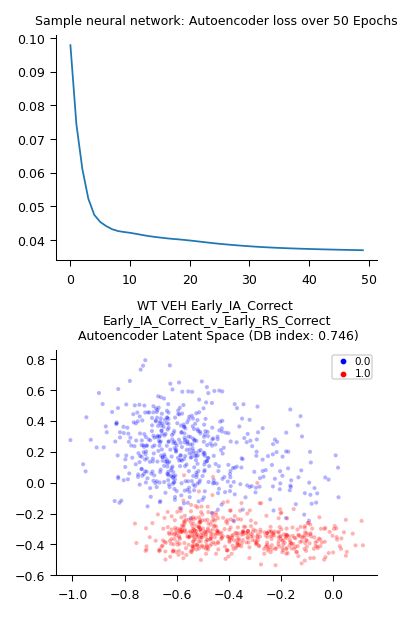

In [27]:
if plot_sample_nn:    #tailor NN for current data
    fig, ax_array = plt.subplots(2,1, figsize = (2.5,4), layout ='constrained')
    ax = ax_array[0]
    ax.plot(loss)
    ax.set_title(f'Sample neural network: Autoencoder loss over {numEpochs} Epochs')
    ### Plot latent space representation color-coded 
    ax = ax_array[1]
    with torch.no_grad():
        embed, labels =   lightning_encode(model,test_loader)##push test data throuhg encoder
    scatter = sns.scatterplot(ax = ax, x = embed[:,0], y = embed[:,1], hue =labels, palette = ['blue', 'red'], alpha = 0.3) # legend1 = ax.legend(*scatter.legend_elements()) ### according to their "true" labels
    set_labels(ax = ax, label_dict ={'title':f'{geno} {ensemble} \n{comparison}\n Autoencoder Latent Space (DB index: {round(davies_bouldin_score(embed, labels),3)})'}) #get DB index: 
    ##save fig
    fig_name = f"Sample Autoencoder ({ensemble} in {comparison})_Loss_Latent space ({numEpochs} epochs) {date_tag}"
    [fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

## Setup Bootstrap per NN model to get DB index of latent space

In [28]:
def train_model_return_embed(dropout_net, 
                             n_cells,
                             train_loader,
                             test_loader,
                             n_epoch = 50,
                             dropout = 0,):
    ''' To create 1 models then return training points in latent space ''' 
    model =  LitAutoEncoder(dropout_net, layer_1_input=n_cells,dropout = dropout)### Instantiate your model
    history = LossHistory()
    trainer = L.Trainer(enable_model_summary=False, 
                        enable_progress_bar=False,
                        accelerator="cpu",    # ← force CPU
                        enable_checkpointing=False,
                        max_epochs=n_epoch,
                        log_every_n_steps=2,
                        callbacks = [history],)
    trainer.fit(model, train_loader);
    loss = history.train_losses #project data
    model.freeze()
    with torch.no_grad():
        embed, labels =   lightning_encode(model,test_loader)##push test data throuhg encoder
    return model, (embed, labels)
    
def train_model_get_DB_index(dropout_net, 
                             n_cells,
                            train_loader,
                            test_loader,
                            ensemble = 'Early_IA_Correct',
                            geno_day= "WT VEH",
                            comparison = 'Early_IA_Correct_v_Early_RS_Correct',
                            n_epoch = 50,
                            dropout = 0,
                            model_iter = 0):
    ''' To create B models over N epochs, then return DB index of latent space with run info appended. ''' 
    model, (embed, labels) =  train_model_return_embed(dropout_net, n_cells, train_loader, test_loader, n_epoch = 50, dropout = 0,)
    DB_index = davies_bouldin_score(embed, labels)
        #combine/store data
    run_info = dict(model_run =model_iter, 
                    DB_index = DB_index,
                    n_epochs = n_epoch,
                    final_loss = loss[-1],
                    ensemble = ensemble,
                    geno_day= geno_day,
                    comparison = comparison,
                    lossDelta = round(loss[0]-loss[-1],4))
    return run_info



In [29]:
def make_train_model_get_DB(n_cells,
                            class_matrix_store,
                            ensemble = 'Early_IA_Correct',
                            geno_day= "WT VEH",
                            comparison = 'Early_IA_Correct_v_Early_RS_Correct',
                            n_epoch = 50,
                            n_frames_to_draw = 500,
                            dropout = 0,
                            model_run:list= [0]):
    ''' Pass in raw data to resample then build dataloaders around. Resamples B datasets for B models in bootstrap'''
    #extract and reasmple data 
    class_0, class_1 = comparison.split("_v_") # print(class_0, class_1)    
    #run B bootstraps
    run_results = []
    for b in model_run: #make sure is list to iterate over 
        ensemble_resample_in_phase_dict = resample_ensemble_stage_activity(class_matrix_store,n_frames_to_draw,ensemble, geno_day, stages_to_resample= [class_0, class_1])
        long_concat_matrix,long_concat_labels =fast_pack_data_local(ensemble_resample_in_phase_dict[class_0], ensemble_resample_in_phase_dict[class_1],0,1)        #returns concat_matrix, and concat_labels
        train_dataset, test_dataset= return_train_test_tensorDataset(long_concat_matrix, long_concat_labels, shuffle = True)
        train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=500, shuffle=False,num_workers=0,persistent_workers=False)
        test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=500, shuffle=False,num_workers=0)
        n_cells = long_concat_matrix.shape[0]
        
        bootstrap_output = train_model_get_DB_index(dropout_net, 
                                                    n_cells,
                                                    train_loader,
                                                    test_loader,
                                                    ensemble = ensemble,
                                                    geno_day= geno_day,
                                                    comparison = comparison,
                                                    n_epoch = 50,
                                                    dropout = 0,
                                                    model_iter = b)
        ##get mean activity per class of bootstrap
        class_1_mean = round(ensemble_resample_in_phase_dict[class_0].values.mean(),4)
        class_2_mean = round(ensemble_resample_in_phase_dict[class_1].values.mean(),4)
        run_info = {**bootstrap_output, 'class_1_mean': class_1_mean, 'class_2_mean': class_2_mean}
        run_results.append(run_info)
    return run_results

In [30]:
dropout_level = 0.00

partial_param_nn_train = partial(make_train_model_get_DB,
                                 n_cells = n_cells,
                                 class_matrix_store=class_matrix_store,
                                 n_epoch = 50,
                                 ensemble = 'Early_IA_Correct', 
                                 geno_day= geno_order[0],
                                 comparison = 'Early_IA_Correct_v_Early_RS_Correct',
                                 dropout = dropout_level,)
partial_param_nn_train
partial_param_nn_train(model_run=[0,1])

[{'model_run': 0,
  'DB_index': 0.8124465478495784,
  'n_epochs': 50,
  'final_loss': 0.03700422868132591,
  'ensemble': 'Early_IA_Correct',
  'geno_day': 'WT VEH',
  'comparison': 'Early_IA_Correct_v_Early_RS_Correct',
  'lossDelta': 0.0609,
  'class_1_mean': 0.0763,
  'class_2_mean': 0.0317},
 {'model_run': 1,
  'DB_index': 0.7886160985666859,
  'n_epochs': 50,
  'final_loss': 0.03700422868132591,
  'ensemble': 'Early_IA_Correct',
  'geno_day': 'WT VEH',
  'comparison': 'Early_IA_Correct_v_Early_RS_Correct',
  'lossDelta': 0.0609,
  'class_1_mean': 0.0761,
  'class_2_mean': 0.0312}]

In [31]:
import psutil
#16 physical cores to use 
total_cpu_physical = psutil.cpu_count(logical=False)
print(total_cpu_physical)
n_jobs= total_cpu_physical

4


In [32]:

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')


Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [33]:
run_single_bootstrap = True
start_val = 0
end_val = 100
start_end_iter = make_chunked_iterator_of_ranges(start_val,end_val, n_jobs)

if run_single_bootstrap:
    print(start_end_iter)
    output_nn = Parallel(n_jobs= n_jobs, backend="loky", verbose = 9)(delayed(partial_param_nn_train)(model_run=x) for x in start_end_iter) # 10 jobs, 500 iters, = 16 minutes with 500 samples/class fed in  (backend- Loky + CPU train )
    job_records = [pd.DataFrame.from_records(x) for x in output_nn]
    bootstrap_jobs = pd.concat(job_records)
    print(bootstrap_jobs.sample())
    bootstrap_jobs.to_parquet("test_bootstrap.parquet")
    save_to_gcs("test_bootstrap.parquet", "test_folder/test_bootstrap.parquet")


N_batches: 4
Batch_size: 25
[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24]), array([25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41,
       42, 43, 44, 45, 46, 47, 48, 49]), array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73, 74]), array([75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91,
       92, 93, 94, 95, 96, 97, 98, 99])]


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:   30.6s remaining:   30.6s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:   31.5s finished


   model_run  DB_index  n_epochs  final_loss          ensemble geno_day  \
6         31  1.091883        50    0.037004  Early_IA_Correct   WT VEH   

                            comparison  lossDelta  class_1_mean  class_2_mean  
6  Early_IA_Correct_v_Early_RS_Correct     0.0609        0.0762        0.0309  
Uploaded: gs://colab_autoencoder_output/test_folder/test_bootstrap.parquet


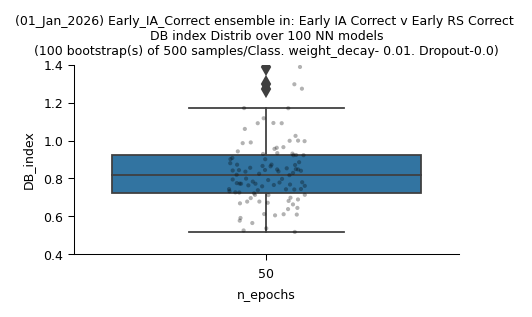

In [34]:
if run_single_bootstrap:
    DB_of_epoch = bootstrap_jobs
    #plot N NN runs
    fig,ax = plt.subplots(1,1,figsize = (3,2), layout = 'constrained')
    sns.boxplot(data = DB_of_epoch, x = 'n_epochs', hue = 'geno_day', y = 'DB_index', dodge = False)#showcaps=False,fliersize = 0)
    sns.stripplot(data = DB_of_epoch, x = 'n_epochs', hue = 'geno_day', y = 'DB_index', palette = ['black'], alpha = 0.3, s = 2,dodge = False)#showcaps=False,fliersize = 0)
    
    set_labels(ax, label_dict = {'legend_false':True, 'ylim': [0.4, 1.4],
        'title': f"({date_tag}) {ensemble} ensemble in: {comparison.replace("_", " ")} \n" + 
        f" DB index Distrib over {DB_of_epoch.model_run.nunique()} NN models \n"+ 
                                 f"({end_val} bootstrap(s) of 500 samples/Class. weight_decay- {weight_decay}. Dropout-{dropout_level})"})
    ##save fig
    fig_name =f"{DB_of_epoch.model_run.nunique()} NN runs- {ensemble} ens- DB index {end_val} Bootstrap {dropout_level} dropout_decay {weight_decay} _{date_tag}"
    [fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

#### Bootstrap over all combinations 

In [35]:
os.getcwd()
current_run_output

'/content/output//model_results/01_Jan_2026\\'

In [ ]:
from google.cloud import storage
import io
from collections import defaultdict
## GCS reading and import missing code
def get_completed_combos(bucket_name, run_folder):
    """Get (comparison, ensemble, geno) tuples already in GCS."""
    client = storage.Client.from_service_account_json('/content/service_account_key.json')
    bucket = client.bucket(bucket_name)
    
    completed = set()
    for blob in bucket.list_blobs(prefix=run_folder):
        if blob.name.endswith('.parquet'):
            df = pd.read_parquet(io.BytesIO(blob.download_as_bytes()))

            for _, row in df[['comparison', 'ensemble', 'geno_day']].drop_duplicates().iterrows():
                completed.add((row['comparison'], row['ensemble'], row['geno_day']))
    return completed

def get_missing_combos(bucket_name, run_folder, ens_stage_pairs_subset, geno_plot):
    """Return missing (comparison, ensemble, geno) tuples."""
    expected = {(comp, ens, geno) 
                for comp, ens_list in ens_stage_pairs_subset.items() 
                for ens in ens_list 
                for geno in geno_plot}
    completed = get_completed_combos(bucket_name, run_folder)
    missing = expected - completed
    print(f"Expected: {len(expected)} | Completed: {len(completed)} | Missing: {len(missing)}")
    #transform into format aligned with bootstrap loop input
    missing_dict = defaultdict(set) # init with set to force unique values only
    for comp, ens, geno in missing:
        missing_dict[comp].add(ens)
    missing_dict = {k: list(v) for k, v in missing_dict.items()}
    return missing_dict
#test


In [37]:
# last_bootstrap_run = "//data//NN 1000 bootstrap_ DB index results_24_Jun_2025.parquet"
# load_last_bootstrap_output = False
#set parameters 
ens_stage_pairs_subset = {'Early_IA_Correct_v_Early_RS_Correct':['Early_IA_Correct', 'Early_RS_Correct'],
                              'Early_IA_Error_v_Early_RS_Error':['Early_IA_Error', 'Early_RS_Error'],
                              'Late_IA_v_Early_RS_Correct':['Late_IA', 'Early_RS_Correct'],
                              'Early_IA_Correct_v_Late_IA':['Early_IA_Correct','Late_IA'] }
geno_plot = geno_order_w_WT_CLNZ
#4 physical cores to use- in google high ram 
#4 cores, 1000 shuffles - 5 min per Geno X Ensemble X Compared
start_val = 0
end_val = 10000
#input data- stage_resample_by_geno_ensemble = ensemble > geno > stage activity
start_end_iter = make_chunked_iterator_of_ranges(start_val,end_val, n_jobs)
print(start_end_iter)
## set params for loop
dropout_level = 0.00
bootstrap_NN = True

# NEW- complete missing run settings
complete_partial_run = True
BUCKET = 'colab_autoencoder_output'
RUN_FOLDER = '/content/output//model_results/30_Dec_2025\\'

##  MAIN AUTOENC LOOP
bootstrap_storage = []
if bootstrap_NN:    #10000 bootstraps- 31271.23s/it ~9 hours per comp per compoarison, 1 hour per each section,  
    ## new- check for previous run, evaluate pairs to still run
    if complete_partial_run: 
        print(f"Completing partial run from: {RUN_FOLDER}")
        missing = get_missing_combos(bucket_name = BUCKET, run_folder= RUN_FOLDER, 
                             ens_stage_pairs_subset= ens_stage_pairs_subset,
                             geno_plot = geno_order_w_WT_CLNZ)
        #update vars to complete previous run
        ens_stage_pairs_subset = missing
        current_run_output = RUN_FOLDER
    for comparison, ensemble_list in tqdm(ens_stage_pairs_subset.items()):            # print(f" Decoding stages {comparison} for ensembles {ensemble_list}")
        class_0, class_1 = comparison.split("_v_") # print(class_0, class_1)
        for ensemble in ensemble_list: #iterate over all ensembles(comparisons are locked to 1 per ensemble list
            for g_count, geno in enumerate(geno_plot): #iterate over geno days    
                print(f" {comparison} - {ensemble} {geno} autoencoder run")
                ### freeze function, creates bootstrap per run
                partial_param_nn_train = partial(make_train_model_get_DB,
                                                    n_cells = n_cells,
                                                    class_matrix_store=class_matrix_store,
                                                    n_epoch = 50,
                                                    ensemble = ensemble, 
                                                    geno_day= geno,
                                                    comparison = comparison,
                                                    dropout = dropout_level,)
                # ## run job in paralell 
                output_nn = Parallel(n_jobs= n_jobs, backend="loky", verbose = 9)(delayed(partial_param_nn_train)(model_run=x) for x in start_end_iter) # 10 jobs, 500 iters, = 16 minutes with 500 samples/class fed in  (backend- Loky + CPU train )
                #save.concat paralell output
                job_records = [pd.DataFrame.from_records(x) for x in output_nn]
                bootstrap_jobs = pd.concat(job_records)
                bootstrap_storage.append(bootstrap_jobs) #list of DFs with info on B NNs created/                
                # NEW: === PERIODIC SAVE ===
                
                checkpoint_file = current_run_output + f"{comparison} - {ensemble} {geno} autoencoder_bootstrap_{date_tag}.parquet"
                bootstrap_output = pd.concat(bootstrap_storage)
                bootstrap_output.to_parquet(checkpoint_file)
                save_to_gcs(checkpoint_file, checkpoint_file)
                print(f"Checkpoint saved: {comparison}/{ensemble}/{geno} - Total: {len(bootstrap_output)} rows")

# bootstrap_output = pd.concat(bootstrap_storage)
#save database of B shuff
# nn_bootstrap_filename  = current_run_output + f"NN {end_val} bootstrap_ DB index results_{date_tag}.parquet"
# print(f"saved bootstrap output file: {nn_bootstrap_filename}")
# bootstrap_output.to_parquet(nn_bootstrap_filename)
# save_to_gcs(nn_bootstrap_filename, nn_bootstrap_filename)

#regardless of choice for acquiring df, print info
# print(bootstrap_output.info())
# bootstrap_output.head()

N_batches: 4
Batch_size: 2500
[array([   0,    1,    2, ..., 2497, 2498, 2499]), array([2500, 2501, 2502, ..., 4997, 4998, 4999]), array([5000, 5001, 5002, ..., 7497, 7498, 7499]), array([7500, 7501, 7502, ..., 9997, 9998, 9999])]
Completing partial run from: /content/output//model_results/30_Dec_2025\
Expected: 40 | Completed: 39 | Missing: 1


  0%|          | 0/1 [00:00<?, ?it/s]

 Late_IA_v_Early_RS_Correct - Early_RS_Correct WT VEH autoencoder run


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed: 38.7min remaining: 38.7min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed: 38.9min finished


Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\Late_IA_v_Early_RS_Correct - Early_RS_Correct WT VEH autoencoder_bootstrap_01_Jan_2026.parquet
Checkpoint saved: Late_IA_v_Early_RS_Correct/Early_RS_Correct/WT VEH - Total: 10000 rows
 Late_IA_v_Early_RS_Correct - Early_RS_Correct WT CLNZ autoencoder run


...

Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\Late_IA_v_Early_RS_Correct - Early_RS_Correct Het CLNZ autoencoder_bootstrap_01_Jan_2026.parquet
Checkpoint saved: Late_IA_v_Early_RS_Correct/Early_RS_Correct/Het CLNZ - Total: 40000 rows
 Late_IA_v_Early_RS_Correct - Early_RS_Correct Het postCLNZ autoencoder run


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed: 50.8min remaining: 50.8min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed: 51.2min finished
100%|██████████| 1/1 [3:45:57<00:00, 13557.40s/it]

Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\Late_IA_v_Early_RS_Correct - Early_RS_Correct Het postCLNZ autoencoder_bootstrap_01_Jan_2026.parquet
Checkpoint saved: Late_IA_v_Early_RS_Correct/Early_RS_Correct/Het postCLNZ - Total: 50000 rows
saved bootstrap output file: /content/output//model_results/30_Dec_2025\NN 10000 bootstrap_ DB index results_01_Jan_2026.parquet


Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\NN 10000 bootstrap_ DB index results_01_Jan_2026.parquet
<class 'pandas.core.frame.DataFrame'>
Int64Index: 50000 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model_run     50000 non-null  int64  
 1   DB_index      50000 non-null  float64
 2   n_epochs      50000 non-null  int64  
 3   final_loss    50000 non-null  float64
 4   ensemble      50000 non-null  object 
 5   geno_day      50000 non-null  object 
 6   comparison    50000 non-null  object 
 7   lossDelta     50000 non-null  float64
 8   class_1_mean  50000 non-null  float64
 9   class_2_mean  50000 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 4.2+ MB
None


,model_run,DB_index,n_epochs,final_loss,ensemble,geno_day,comparison,lossDelta,class_1_mean,class_2_mean
0,0,1.098547,50,0.037004,Early_RS_Correct,WT VEH,Late_IA_v_Early_RS_Correct,0.0609,0.0455,0.0899
1,1,0.889131,50,0.037004,Early_RS_Correct,WT VEH,Late_IA_v_Early_RS_Correct,0.0609,0.0460,0.0925
2,2,1.533867,50,0.037004,Early_RS_Correct,WT VEH,Late_IA_v_Early_RS_Correct,0.0609,0.0469,0.0899
3,3,1.686780,50,0.037004,Early_RS_Correct,WT VEH,Late_IA_v_Early_RS_Correct,0.0609,0.0451,0.0923
4,4,1.574533,50,0.037004,Early_RS_Correct,WT VEH,Late_IA_v_Early_RS_Correct,0.0609,0.0469,0.0901


#### save current run with any additional previous runs

In [38]:

# Load previous checkpoints from GCS and combine with current run
def load_all_checkpoints(bucket_name, run_folder):
    """Load and concatenate all checkpoint parquets from GCS."""
    client = storage.Client.from_service_account_json('/content/service_account_key.json')
    bucket = client.bucket(bucket_name)
    
    dfs = []
    for blob in bucket.list_blobs(prefix=run_folder):
        if blob.name.endswith('.parquet'):
            dfs.append(pd.read_parquet(io.BytesIO(blob.download_as_bytes())))
    return pd.concat(dfs) if dfs else pd.DataFrame()

# Check how many results have been collected
print(f"Bootstrap storage length: {len(bootstrap_storage)}")
if bootstrap_storage:
    print(f"Total rows collected: {sum(len(df) for df in bootstrap_storage)}")

# Combine previous + current, deduplicate, save
previous_output = load_all_checkpoints(BUCKET, RUN_FOLDER)
bootstrap_output = pd.concat([previous_output, pd.concat(bootstrap_storage)]).drop_duplicates()

# Save final combined output
nn_bootstrap_filename = f"NN {end_val} bootstrap_DB_index_results_{date_tag}.parquet"
bootstrap_output.to_parquet(f"/content/{nn_bootstrap_filename}")
save_to_gcs(f"/content/{nn_bootstrap_filename}", f"{RUN_FOLDER}/{nn_bootstrap_filename}")

print(f"Saved: {len(bootstrap_output)} rows ({len(previous_output)} previous + {len(pd.concat(bootstrap_storage))} new)")
bootstrap_output.info()

Bootstrap storage length: 5
Total rows collected: 50000
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\/NN 10000 bootstrap_DB_index_results_01_Jan_2026.parquet
Saved: 415000 rows (3465000 previous + 50000 new)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 415000 entries, 0 to 249
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   model_run     415000 non-null  int64  
 1   DB_index      415000 non-null  float64
 2   n_epochs      415000 non-null  int64  
 3   final_loss    415000 non-null  float64
 4   ensemble      415000 non-null  object 
 5   geno_day      415000 non-null  object 
 6   comparison    415000 non-null  object 
 7   lossDelta     415000 non-null  float64
 8   class_1_mean  415000 non-null  float64
 9   class_2_mean  415000 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 34.8+ MB


[None, None]

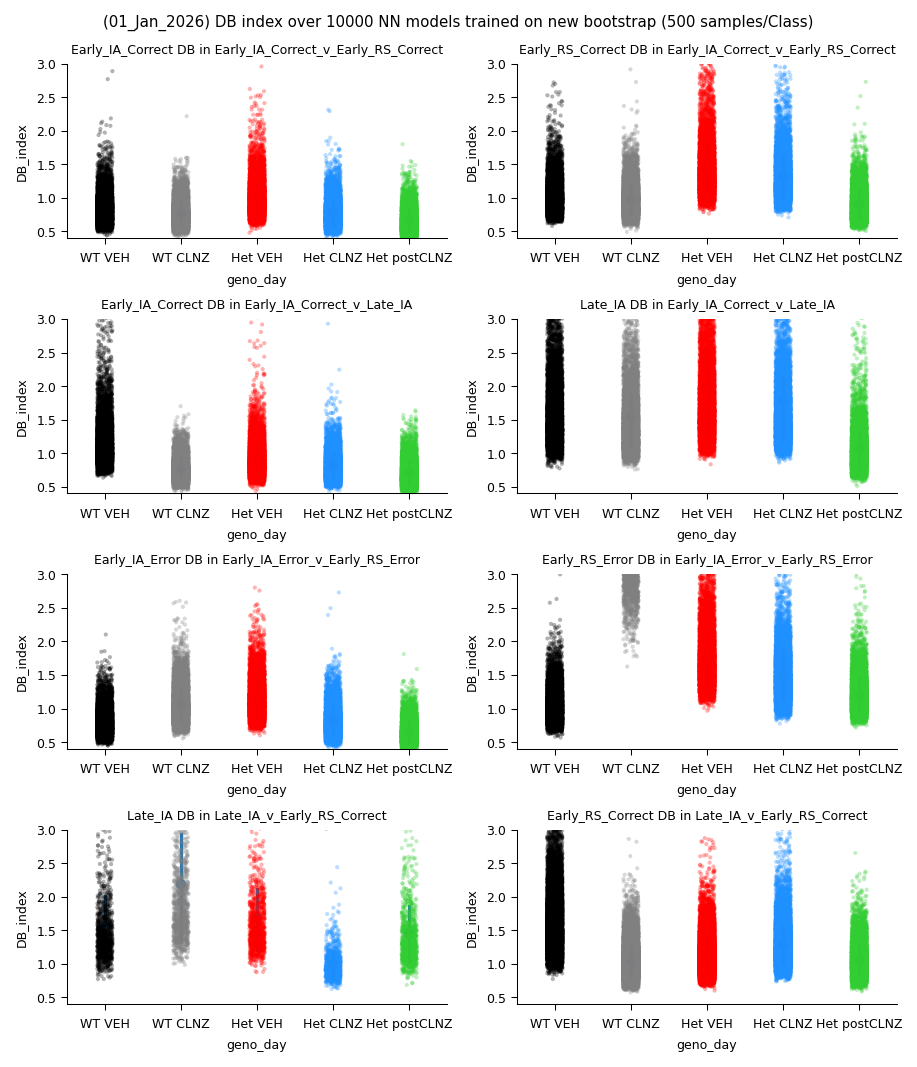

In [42]:
ens_stage_pairs_subset = {'Early_IA_Correct_v_Early_RS_Correct':['Early_IA_Correct', 'Early_RS_Correct'],
                              'Early_IA_Error_v_Early_RS_Error':['Early_IA_Error', 'Early_RS_Error'],
                              'Late_IA_v_Early_RS_Correct':['Late_IA', 'Early_RS_Correct'],
                              'Early_IA_Correct_v_Late_IA':['Early_IA_Correct','Late_IA'] }
#plot N NN runs
fig,ax_array = plt.subplots(len(bootstrap_output.comparison.unique()),2, figsize = (6,7), layout = 'constrained')
for c, comparison in enumerate(bootstrap_output.comparison.unique()):
    for e, ens in enumerate(ens_stage_pairs_subset[comparison]):
        ax = ax_array[c,e]
        facet_mask = (bootstrap_output.comparison == comparison) & (bootstrap_output.ensemble ==ens)
        plot_db = bootstrap_output.loc[facet_mask, :]
        sns.pointplot(ax = ax, data = plot_db, x = 'geno_day',  y = 'DB_index', order = geno_order_w_WT_CLNZ, linestyles = 'None', dodge = False,errorbar = ('pi', 75))#showcaps=False,fliersize = 0)
        sns.stripplot(ax = ax, data =plot_db, x = 'geno_day', y = 'DB_index', **geno_order_w_WT_CLNZ_no_eb, alpha = 0.3, s = 2,dodge = False)#showcaps=False,fliersize = 0)
        set_labels(ax, label_dict = {'legend_false':True, 'ylim': [0.4, 3], 'title': f"{ens} DB in {comparison}"})
    
##save fig
fig.suptitle(f"({date_tag}) DB index over {end_val} NN models trained on new bootstrap (500 samples/Class)")
fig_name =f"{end_val} NN boostrap-  DB index with {dropout_level} dropout_decay {weight_decay} _{date_tag}"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

#### Create Latent Space Viz- 1 autoencoder per comparison x ensembles

In [43]:
def save_metadata_record(last_run_metadata_record:pd.DataFrame, metadata_record_filename:str, save_loc:str):
    #write filename to dF
    
    if not os.path.exists(metadata_record_filename):    #create locally then save
        print(f"creating autoencoder versioning file: {metadata_record_filename}")
        last_run_metadata_record.to_csv(metadata_record_filename,index = False)
    else: #load existing and add to it 
        print(f"Loading autoencoder versioning file: {metadata_record_filename}")
        metadata_record= pd.read_csv(metadata_record_filename)
        metadata_record = pd.concat([metadata_record, last_run_metadata_record]) #join prev df with latest DF
        #save multiple backups 
        # metadata_record.to_csv(metadata_record_filename) 
        metadata_record.to_csv(save_loc + metadata_record_filename)
        metadata_record.to_csv(csv_folder_most_recent +metadata_record_filename)
        metadata_record.to_csv(csv_folder_current_run + metadata_record_filename)


In [49]:
print(os.getcwd())
#preset the storage output name:
torch_model_storage = os.getcwd() + f"/torch_model_storage_{date_tag}"
print(f'saving to {torch_model_storage}')
make_folder(torch_model_storage)

/content
saving to /content/torch_model_storage_01_Jan_2026
Created folder: /content/torch_model_storage_01_Jan_2026


'/content/torch_model_storage_01_Jan_2026'

In [50]:
run_autoencoder=True
save_model = True

In [75]:
import json

#set the dataset filters to use when making things 
ensemble_plot = ['Early_IA_Correct', 'Early_RS_Correct', 'Early_IA_Error', 'Early_RS_Error'] #what ensembles do you care about
geno_plot =  geno_order_w_WT_CLNZ
decode_plot = ['Early_IA_Correct_v_Early_IA_Error', 'Early_IA_Correct_v_Early_RS_Correct', 'Early_IA_Error_v_Early_RS_Error', 'Early_RS_Correct_v_Early_RS_Error'] #what class comparisons do you care about
run_info_list = [] #store the gathered data
## set params for current run 
run_params = dict(dropout = 0.05, numEpochs = 50,n_frames_to_draw= 500, BATCH_SIZE = 250, NUM_WORKERS = 2, test_on_train= False,lr=0.0125)#gather into run params
if run_params['test_on_train']:
    run_params['n_frames_to_draw']= run_params['n_frames_to_draw']*2
## MAIN AUTOENC LOOP
ens_stage_pairs_subset = {'Early_IA_Correct_v_Early_RS_Correct':['Early_IA_Correct', 'Early_RS_Correct'],
                          'Early_IA_Error_v_Early_RS_Error':['Early_IA_Error', 'Early_RS_Error'],
                          'Late_IA_v_Early_RS_Correct':['Late_IA', 'Early_RS_Correct'],
                          'Early_IA_Correct_v_Late_IA':['Early_IA_Correct','Late_IA'] }
if run_autoencoder:
    make_folder(torch_model_storage)
    for comparison, ensemble_list in tqdm(ens_stage_pairs_subset.items()):            # print(f" Decoding stages {comparison} for ensembles {ensemble_list}")
        class_0, class_1 = comparison.split("_v_") # print(class_0, class_1)
        for ensemble in ensemble_list: #iterate over all ensembles(comparisons are locked to 1 per ensemble list
            for g_count, geno in enumerate(geno_plot): #iterate over geno days             
                ensemble_resample_in_phase_dict = resample_ensemble_stage_activity(class_matrix_store,n_frames_to_draw,ensemble, geno, stages_to_resample= stage_names)
                long_concat_matrix,long_concat_labels =fast_pack_data_local(ensemble_resample_in_phase_dict[class_0], ensemble_resample_in_phase_dict[class_1],0,1)        #returns concat_matrix, and concat_labels
                train_dataset, test_dataset= return_train_test_tensorDataset(long_concat_matrix, long_concat_labels, shuffle = True,test_on_train = run_params['test_on_train'])
                n_cells = long_concat_matrix.shape[0]
                train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=run_params['BATCH_SIZE'],pin_memory= False, shuffle=True,num_workers=run_params['NUM_WORKERS'],persistent_workers=True)
                test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=run_params['BATCH_SIZE'],pin_memory= False, shuffle=True,num_workers=run_params['NUM_WORKERS'])
                ### Instantiate your model
                model, (embed,labels) =  train_model_return_embed(dropout_net, n_cells,train_loader,test_loader,n_epoch = 50,dropout = 0,)
                # #save info
                run_info = dict(classes_decoded = comparison, 
                                geno_day= geno,
                                ensemble = ensemble,
                                class_0 = class_0,
                                class_1 = class_1, 
                                n_frames = long_concat_matrix.shape[0],
                                num_epochs = run_params['numEpochs'], 
                                mean_loss = np.mean(loss[-10:]),
                                n_cells = n_cells, 
                                dropout = run_params['dropout'], 
                                test_on_train=run_params['test_on_train'],
                               date_run = date_tag)
                ##freeze and save model for more embeddings later
                if save_model:
                    model_name = torch_model_storage+ f'/model_{"_".join([comparison,geno,ensemble])}.pt'
                    torch.save(model.state_dict(), model_name)
                    save_to_gcs(model_name, f"{RUN_FOLDER}/{model_name}")

                    # trainer.save_checkpoint(torch_model_storage+ f'model_checkpoint_{"_".join([comparison,geno,ensemble,".ckpt"])}')
                #Test data- create embeddings 
                embed_df = pd.DataFrame(np.hstack([embed, labels[:,np.newaxis]]), columns = ['embed_1', 'embed_2', 'labels']).assign(**run_info)       
                ##convert categories for space efficiency
                conversion_cols = dict(classes_decoded = 'category', geno_day= 'category', ensemble = 'category',class_0 = 'category', class_1 = 'category', n_frames = 'Int64',date_run = 'category',labels= 'category')
                embed_df.loc[:, list(conversion_cols.keys())] = embed_df.loc[:, list(conversion_cols.keys())].astype(conversion_cols)
                run_info_list.append(embed_df)
    #save run params 
    embed_record = pd.concat(run_info_list)
    embed_record["labels"]= np.where(embed_record["labels"] == 0.0, embed_record["class_0"], embed_record["class_1"])
    
    filename = torch_model_storage+ f"/run_param_{date_tag}.json"
    with open(filename, 'w') as file:
        json.dump(run_params, file,indent=2)
    save_to_gcs(filename, f"{RUN_FOLDER}/run_params.json")  #  strings


  0%|          | 0/4 [00:00<?, ?it/s]

Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Early_RS_Correct_WT VEH_Early_IA_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Early_RS_Correct_WT CLNZ_Early_IA_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Early_RS_Correct_Het VEH_Early_IA_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Early_RS_Correct_Het CLNZ_Early_IA_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Early_RS_Correct_Het postCLNZ_Early_IA_Correct.pt
Uploaded: gs://colab

 25%|██▌       | 1/4 [00:15<00:46, 15.63s/it]

Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Early_RS_Correct_Het postCLNZ_Early_RS_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Error_v_Early_RS_Error_WT VEH_Early_IA_Error.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Error_v_Early_RS_Error_WT CLNZ_Early_IA_Error.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Error_v_Early_RS_Error_Het VEH_Early_IA_Error.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Error_v_Early_RS_Error_Het CLNZ_Early_IA_Error.pt
Uploaded: gs://colab_autoencoder_output//con

 50%|█████     | 2/4 [00:30<00:30, 15.19s/it]

...

 75%|███████▌  | 3/4 [00:45<00:15, 15.21s/it]

Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Late_IA_v_Early_RS_Correct_Het postCLNZ_Early_RS_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Late_IA_WT VEH_Early_IA_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Late_IA_WT CLNZ_Early_IA_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Late_IA_Het VEH_Early_IA_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Late_IA_Het CLNZ_Early_IA_Correct.pt
Uploaded: gs://colab_autoencoder_output//content/output//model_re

100%|██████████| 4/4 [01:01<00:00, 15.28s/it]

Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/model_Early_IA_Correct_v_Late_IA_Het postCLNZ_Late_IA.pt


Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\/run_params.json


In [78]:
autoencoder_record = 'last_autoencoder_run_info.txt'
autoencoder_run_versions = f"autoencoder project- run version record_{date_tag}.csv"
resample_type_str = {True: f"_Embed Train Data", False: f"_Embed New Data"}
#save files based on conditions
if run_autoencoder:
    #save embed record
    file_name = torch_model_storage + f"/Autoencoder_latent_space_{date_tag}_{run_params['n_frames_to_draw']}Sample.parquet"
    embed_record.to_parquet(file_name, compression='snappy')
    save_to_gcs(file_name, f"{RUN_FOLDER}/{file_name}")  # ✓ strings

    ## save loc of current encoder
    f = open(autoencoder_record, "w")
    autoencode_run_info_str = f"latest autoencoder output filename: {file_name}. Run end: {date_tag}. Data used: {trial_df_filename}"
    f.write(autoencode_run_info_str)
    f.close()
    print(autoencode_run_info_str)
    ## DATA VERSIONING #create run information df
    run_info = {'run_date': date_tag, 
                'run_dataset_used': trial_df_filename,
                'n_epoch': run_params['numEpochs'],
                'n_class_frames':run_params['n_frames_to_draw'],
                'ensembles_ran': [ensemble_plot],
                'classes_ran': [decode_plot],
                'file_name':file_name,
                'test_on_train': run_params['test_on_train'],
                'model_locations': torch_model_storage,
               'lr':0.0125,
                'random_seed': torch.initial_seed(),                
                # Architecture
                'hidden_dim': 9,
                'latent_dim': 2,
                'activation': 'Mish',
                'loss_fn': 'MSE',
                # Training (from run_params)
                'batch_size': run_params['BATCH_SIZE'],
                # Environment
                'torch_version': torch.__version__,
                'lightning_version': L.__version__,
                'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    }
    run_record = pd.DataFrame.from_dict(run_info)
    #write filename to dF
    file_loc = data_folder
    #manually save csv
    run_record.to_csv(data_folder + autoencoder_run_versions)
    save_to_gcs(data_folder + autoencoder_run_versions, autoencoder_run_versions)  # ✓ strings

    # save_metadata_record(last_run_metadata_record=run_record, 
    #                      metadata_record_filename=autoencoder_run_versions,
    #                      save_loc=folder_name)    
else: #if you already have an autoencoder result to open
    run_record= pd.read_csv(data_folder+ autoencoder_run_versions)
    f = open(autoencoder_record, "r")
    autoencode_run_txt = f.read()
    autoencode_filename = autoencode_run_txt.split(': ')[1].split('. Run')[0]
    print(autoencode_filename)
    embed_record =pd.read_parquet(autoencode_filename)
print(run_record.iloc[-5:,:])
embed_record

Uploaded: gs://colab_autoencoder_output//content/output//model_results/30_Dec_2025\//content/torch_model_storage_01_Jan_2026/Autoencoder_latent_space_01_Jan_2026_500Sample.parquet
latest autoencoder output filename: /content/torch_model_storage_01_Jan_2026/Autoencoder_latent_space_01_Jan_2026_500Sample.parquet. Run end: 01_Jan_2026. Data used: /content/data/python-made_trial_timeseries_raster_2025-12-21 12.parquet
Uploaded: gs://colab_autoencoder_output/autoencoder project- run version record_01_Jan_2026.csv
      run_date                                   run_dataset_used  n_epoch  \
0  01_Jan_2026  /content/data/python-made_trial_timeseries_ras...       50   

   n_class_frames                                      ensembles_ran  \
0             500  [Early_IA_Correct, Early_RS_Correct, Early_IA_...   

                                         classes_ran  \
0  [Early_IA_Correct_v_Early_IA_Error, Early_IA_C...   

                                           file_name  test_on_train  \


,embed_1,embed_2,labels,classes_decoded,geno_day,ensemble,class_0,class_1,n_frames,num_epochs,mean_loss,n_cells,dropout,test_on_train,date_run
0,-0.171036,0.373512,Early_IA_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
1,-0.219206,-0.193690,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
2,0.073171,-0.265463,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
3,-0.114741,-0.135120,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
4,0.074610,-0.207436,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.006237,0.514958,Late_IA,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,112,50,0.037174,112,0.05,False,01_Jan_2026
496,0.077233,0.418330,Early_IA_Correct,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,112,50,0.037174,112,0.05,False,01_Jan_2026
497,0.143115,0.666510,Early_IA_Correct,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,112,50,0.037174,112,0.05,False,01_Jan_2026
498,-0.350613,0.506246,Late_IA,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,112,50,0.037174,112,0.05,False,01_Jan_2026


In [66]:
os.getcwd()

'/content'

## Bootstrap density score- embedded

In [67]:
run_latent_embedding_sample= False

ensemble_plot = ['Early_IA_Correct', 'Early_RS_Correct', 'Early_IA_Error', 'Early_RS_Error']
geno_plot =  geno_order
decode_plot = ['Early_IA_Correct_v_Early_IA_Error', 'Early_IA_Correct_v_Early_RS_Correct', 'Early_IA_Error_v_Early_RS_Error', 'Early_RS_Correct_v_Early_RS_Error']
run_info_list = []

#### Run bootstrap projections and/or load previous bootstrap projections

In [68]:
def set_bootstrap_index_every_N_rows(input_df:pd.DataFrame = pd.DataFrame(),
                                     input_filter= ['classes_decoded','ensemble','geno_day'],
                                     n_class_samples:int = 400, 
                                     bootstrap_col_name:str = 'strap'):
    ''' To get every N rows (default N = 400) and assign to a bootstrap index'''
    grouped_df = []
    for group_key, group_df in input_df.groupby(by = input_filter):
        grouped_df.append(group_df.assign(
            **{bootstrap_col_name: group_df.reset_index().index.values//n_class_samples}))
    grouped_df = pd.concat(grouped_df)
    return grouped_df

def balance_labels_of_bootstrap(df:pd.DataFrame, labels:list = [0,1], **kwargs):
    '''' to get label 1 df and label 2 df, recombine then export'''
    ##get labels == 0 df, then labels == 1
    df_1 = df[df['labels'] == labels[0]]
    df_2 = df[df['labels'] == labels[1]]
    # add bootstrap index
    group_df_1 = set_bootstrap_index_every_N_rows(df_1, **kwargs)
    group_df_2 =set_bootstrap_index_every_N_rows(df_2, **kwargs)
    #recombine into bootstrap projections df
    balanced_df = pd.concat([group_df_1,group_df_2], ignore_index=True)
    return balanced_df

#### Check spread by bootstrap iteration

In [69]:
mean_density = bootstrap_output.set_index(['comparison', 'ensemble'])
mean_density

model_run  DB_index  \
comparison                          ensemble                                
Early_IA_Correct_v_Early_RS_Correct Early_IA_Correct          0  0.719025   
                                    Early_IA_Correct          1  0.693106   
                                    Early_IA_Correct          2  0.636072   
                                    Early_IA_Correct          3  0.730562   
                                    Early_IA_Correct          4  0.850938   
...                                                         ...       ...   
Late_IA_v_Early_RS_Correct          Late_IA                 995  2.587606   
                                    Late_IA                 996  1.042605   
                                    Late_IA                 997  1.275586   
                                    Late_IA                 998  1.744592   
                                    Late_IA                 999  1.622794   

                                                      n_epochs  final_loss  \
comparison                          ensemble                                 
Early_IA_Correct_v_Early_RS_Correct Early_IA_Correct        50    0.037260   
                                    Early_IA_Correct        50    0.037260   
                                    Early_IA_Correct        50    0.037260   
                                    Early_IA_Correct        50    0.037260   
                                    Early_IA_Correct        50    0.037260   
...                                                        ...         ...   
Late_IA_v_Early_RS_Correct          Late_IA                 50    0.037542   
                                    Late_IA                 50    0.037542   
                                    Late_IA                 50    0.037542   
                                    Late_IA                 50    0.037542   
                                    Late_IA                 50    0.037542   

                                                          geno_day  lossDelta  \
comparison                          ensemble                                    
Early_IA_Correct_v_Early_RS_Correct Early_IA_Correct        WT VEH     0.0458   
                                    Early_IA_Correct        WT VEH     0.0458   
                                    Early_IA_Correct        WT VEH     0.0458   
                                    Early_IA_Correct        WT VEH     0.0458   
                                    Early_IA_Correct        WT VEH     0.0458   
...                                                            ...        ...   
Late_IA_v_Early_RS_Correct          Late_IA           Het postCLNZ     0.0607   
                                    Late_IA           Het postCLNZ     0.0607   
                                    Late_IA           Het postCLNZ     0.0607   
                                    Late_IA           Het postCLNZ     0.0607   
                                    Late_IA           Het postCLNZ     0.0607   

                                                      class_1_mean  \
comparison                          ensemble                         
Early_IA_Correct_v_Early_RS_Correct Early_IA_Correct        0.0761   
                                    Early_IA_Correct        0.0753   
                                    Early_IA_Correct        0.0772   
                                    Early_IA_Correct        0.0755   
                                    Early_IA_Correct        0.0738   
...                                                            ...   
Late_IA_v_Early_RS_Correct          Late_IA                 0.1083   
                                    Late_IA                 0.1068   
                                    Late_IA                 0.1091   
                                    Late_IA                 0.1047   
                                    Late_IA                 0.1065   

                                                      class_2_mean  
com

#### Plot density score per bootstrap

In [70]:
unique_comparisons = list(set(mean_density.index.get_level_values('comparison')))
unique_comparisons

['Early_IA_Correct_v_Late_IA',
 'Early_IA_Error_v_Early_RS_Error',
 'Late_IA_v_Early_RS_Correct',
 'Early_IA_Correct_v_Early_RS_Correct']

In [71]:
score_df = mean_density
score_type = 'Davies-Bouldin index'
comparison =unique_comparisons[0]
comparison_df =score_df.loc[comparison,:]
ensemble_subset = list(set(comparison_df.index.get_level_values('ensemble')))
print(ensemble_subset)
comparison_df


['Late_IA', 'Early_IA_Correct']


,model_run,DB_index,n_epochs,final_loss,geno_day,lossDelta,class_1_mean,class_2_mean
ensemble,,,,,,,,
Early_IA_Correct,0,1.305375,50,0.037226,WT VEH,0.0652,0.0774,0.0398
Early_IA_Correct,1,1.266958,50,0.037226,WT VEH,0.0652,0.0755,0.0416
Early_IA_Correct,2,1.810407,50,0.037226,WT VEH,0.0652,0.0766,0.0408
Early_IA_Correct,3,1.820448,50,0.037226,WT VEH,0.0652,0.0757,0.0406
Early_IA_Correct,4,0.861059,50,0.037226,WT VEH,0.0652,0.0780,0.0408
...,...,...,...,...,...,...,...,...
Late_IA,9995,0.792236,50,0.037226,Het postCLNZ,0.0652,0.0754,0.1086
Late_IA,9996,1.112077,50,0.037226,Het postCLNZ,0.0652,0.0752,0.1068
Late_IA,9997,0.780865,50,0.037226,Het postCLNZ,0.0652,0.0735,0.1075


NameError: name 'main_run_posthoc_tests_and_get_hue_loc_df' is not defined

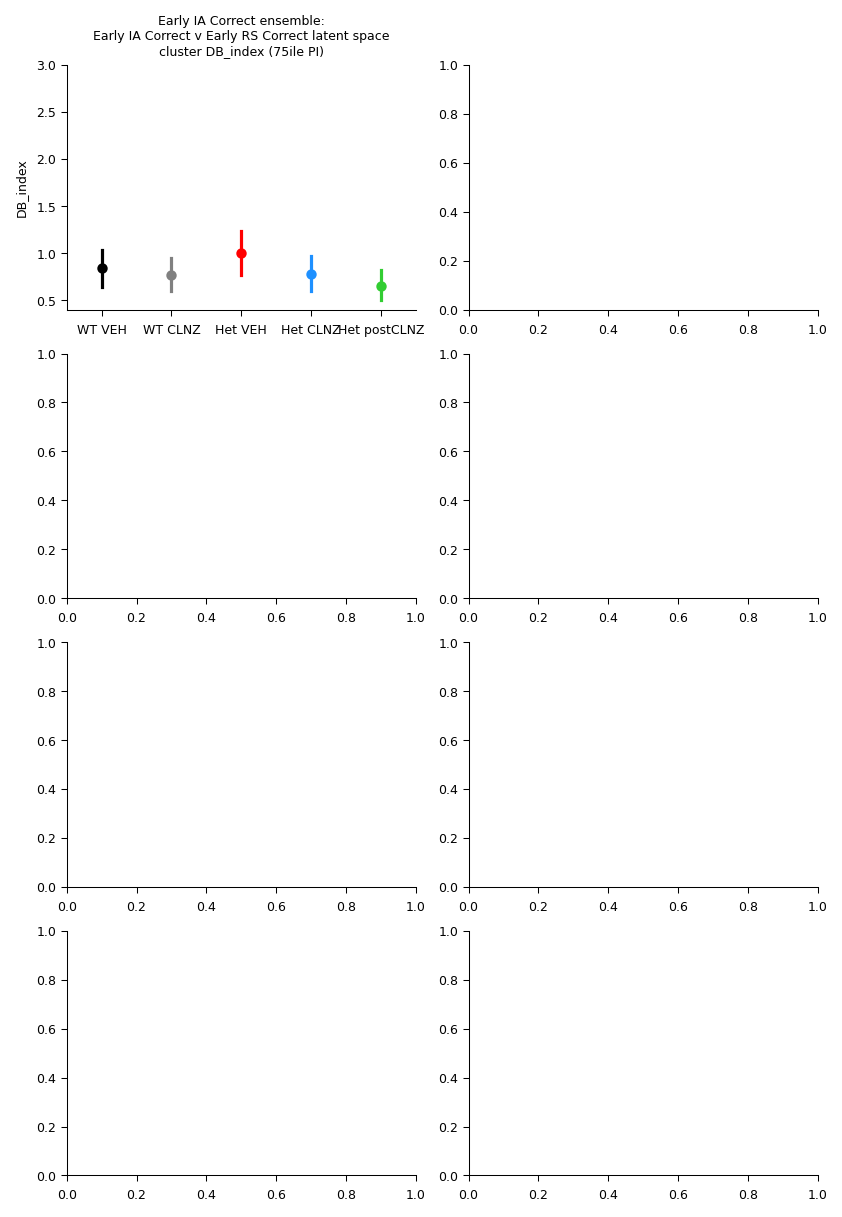

In [72]:

fig_dims = dict(ncols=2,nrows = mean_density.reset_index().comparison.nunique())
fig,ax_array = plt.subplots(**fig_dims, figsize = (2.75*fig_dims['ncols'], 2*fig_dims['nrows']), sharey= False,
                             layout = 'constrained')
score_df = mean_density
score_type = 'DB_index'

# score_type = 'Davies-Bouldin index'
posthoc_list = []
ylim_list = [[0.4,3],
             [0.4,4.5],
             [0.4,2.5],
            [0.4,3]]
stat_test = 'cohen_d'
#iterate over comparisons
for c, comparison in enumerate(mean_density.reset_index().comparison.unique()):
    comparison_df =score_df.loc[comparison,:]
    ensemble_subset = list(set(comparison_df.index.get_level_values('ensemble')))
    for e,ensemble in enumerate(ensemble_subset): #iterate over ensembles
        plot_score =comparison_df.loc[ensemble,:]
        
        plot_ax = ax_array[c,e]
        plot_params = dict(data = plot_score, x = 'geno_day', y =score_type,
                           order = geno_order_w_WT_CLNZ, **format_no_eb_w_WT_CLNZ,)# palette = color_list, order = geno_order, hue_order = geno_order,  hue = 'geno_day')
        sc = sns.pointplot(ax =plot_ax, errorbar = ('pi',75),dodge = False, **plot_params)
        # plot_ax.get_legend().remove()    
        ax_title = f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space\ncluster {score_type} (75ile PI)"
        set_labels(ax =plot_ax, label_dict = {'title': ax_title, 'legend_false': True , 'xlabel': None,'ylim': ylim_list[c]})
        
        ## plot stat annotate
        posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc,
                                                               comparison_list_w_WT_CLNZ, 
                                                               test_name = stat_test,
                                                               ax_var_is_hue=True,detect_error_bar = True)
        plot_sig_bars_w_comp_df_tight(plot_ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.015,offset_constant=0.015) 
        comparison_name=f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space"
        
        posthoc_list.append(posthoc_df.assign(comparison=   comparison_name))
        
posthoc_df = pd.concat(posthoc_list)
##save fig & CSV
n_shuffles = score_df.model_run.max()
fig_name = f"Autoencoder-DB index {n_shuffles} bootstrap (pvalue- {stat_test}) "
fig.suptitle(f"Autoencoder DB index over {n_shuffles} bootstraps (pvalue: robust {stat_test}) ")
#save posthoc CSV
# save_plot_record_as_csv_txt(posthoc_df,folder_pref:="4",fig_name,csv_folder_most_recent, csv_folder_current_run,
#                                 csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

In [ ]:

fig_dims = dict(ncols=2,nrows = mean_density.reset_index().comparison.nunique())
fig,ax_array = plt.subplots(**fig_dims, figsize = (2.75*fig_dims['ncols'], 2*fig_dims['nrows']), sharey= False,
                             layout = 'constrained')
score_df = mean_density
score_type = 'DB_index'

# score_type = 'Davies-Bouldin index'
posthoc_list = []
ylim_list = [[0.4,2.3],
             [0.4,4.05],
             [0.4,2.35],
            [0.4,2.75]]
#iterate over comparisons
for c, comparison in enumerate(mean_density.reset_index().comparison.unique()):
    comparison_df =score_df.loc[comparison,:]
    ensemble_subset = list(set(comparison_df.index.get_level_values('ensemble')))
    for e,ensemble in enumerate(ensemble_subset): #iterate over ensembles
        plot_score =comparison_df.loc[ensemble,:]
        
        plot_ax = ax_array[c,e]
        plot_params = dict(data = plot_score, x = 'geno_day', y =score_type,
                           order = geno_order_w_WT_CLNZ, **format_no_eb_w_WT_CLNZ,)# palette = color_list, order = geno_order, hue_order = geno_order,  hue = 'geno_day')
        sc = sns.boxplot(ax =plot_ax, fliersize =0,dodge = False,saturation = 0.4, **plot_params)
        # plot_ax.get_legend().remove()    
        ax_title = f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space\ncluster {score_type} (75ile PI)"
        
        # ## plot stat annotate
        # posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc,
        #                                                        comparison_list_w_WT_CLNZ, 
        #                                                        test_name = 'permutation_test',ax_var_is_hue=True,detect_error_bar = True)
        # plot_sig_bars_w_comp_df_tight(plot_ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.02,offset_constant=0.015) 
        comparison_name=f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space"
        set_labels(ax =plot_ax, label_dict = {'title': ax_title, 'legend_false': True , 'xlabel': None,'ylim': ylim_list[c]})
        # posthoc_list.append(posthoc_df.assign(comparison=   comparison_name))

fig_name = f"Distribution of Autoencoder DB index over {n_shuffles} bootstraps"
fig.suptitle(fig_name)

#save posthoc CSV
# save_plot_record_as_csv_txt(posthoc_df,folder_pref:="4",fig_name,csv_folder_most_recent, csv_folder_current_run,
#                                 csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

In [ ]:
cols_to_drop = ['y_is_nonnan', 'y_is_2_elem',
                'g_1_child_x','g_1_child_y',
                'g_2_child_x','g_2_child_y',
                'g1_num_loc','g2_num_loc',
                'g1_cat_loc','g2_cat_loc',
                'hue_group_1_locs','hue_group_2_locs',
                'group_1_order_pos', 'group_2_order_pos',
                'group_1_order_pos', 'group_2_order_pos']
all_posthoc = posthoc_df.drop(cols_to_drop, axis = 1)
all_posthoc.to_csv(f"DB index mean diff {stat_test} posthoc test.csv")
all_posthoc

In [ ]:

fig_dims = dict(ncols=2,nrows = mean_density.reset_index().comparison.nunique())
fig,ax_array = plt.subplots(**fig_dims, figsize = (2.5*fig_dims['ncols'], 2*fig_dims['nrows']), sharey= False,
                             layout = 'constrained')
#iterate over comparisons
for c, comparison in enumerate(mean_density.reset_index().comparison.unique()):
    comparison_df =score_df.loc[comparison,:]
    ensemble_subset = list(set(comparison_df.index.get_level_values('ensemble')))
    for e,ensemble in enumerate(ensemble_subset): #iterate over ensembles
        plot_score =comparison_df.loc[ensemble,:]
        
        plot_ax = ax_array[c,e]
        plot_params = dict(data = plot_score, x = 'geno_day', y =score_type,
                           order = geno_order_w_WT_CLNZ, **format_no_eb_w_WT_CLNZ,)# palette = color_list, order = geno_order, hue_order = geno_order,  hue = 'geno_day')
        sc = sns.pointplot(ax =plot_ax, errorbar = ('pi',75),dodge = False, **plot_params)
        # plot_ax.get_legend().remove()    
        ax_title = f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space\ncluster {score_type} (75ile PI)"

In [ ]:
def return_winsorized_data(data:np.array,bounds = [20,80]):
    percentile_lim =  [np.percentile(data, bounds[0]), np.percentile(data, bounds[1])]
    data_winsor = data.copy()
    data_winsor[data_winsor < percentile_lim[0]] = percentile_lim[0]
    data_winsor[data_winsor > percentile_lim[1]] = percentile_lim[1]
    return data_winsor

In [ ]:
comparison_df

In [ ]:
csv_folder_most_recent =output_folder+f"most_recent_analysis_CSV_storage/"
csv_folder_current_run =output_folder+f"analysis_CSV_storage_{date_tag}/" 
#make current folder 
make_folder( csv_folder_most_recent)
make_folder( csv_folder_current_run)

In [ ]:
def plot_db_index_by_ensemble(ax_array, comparison, ensemble_subset, score_df: pd.DataFrame, ylim = [0, 1.5],
                              score_type = 'DB_index',
                              **kwargs):
    """
    Plots ensemble comparison using seaborn pointplot, annotates statistical significance, and appends posthoc results to a provided list.
    Parameters:
    - ensemble_subset (list): List of ensemble identifiers to plot.
    - score_df (pd.DataFrame): DataFrame containing the scores.
    - comparison (str): Identifier for the comparison condition.
    - color_list (list): Colors for plotting.
    - geno_order (list): Order of genotypes for consistent plotting.
    - ax_array (array-like): Array of matplotlib axes to use for subplots.
    - preset_comparison_list (list): Pairs or groups for statistical comparison.
    Returns:
    - - posthoc_list (list): External list to store posthoc result DataFrames. 
    """

    #default args
    fig_suptitle = f"{comparison.replace("_", " ").replace(" v ", " & ")}\n stage activity separation"    # fig_suptitle = f"Separation of activity in\n{comparison.replace("_", " ").replace(" v ", " & ")}stages"
    fig.suptitle(fig_suptitle, fontsize = 6)
    
    posthoc_list= []        
    for e,ensemble in enumerate(ensemble_subset):
        plot_ax = ax_array[e]
        print(store_type)
        plot_params = dict( data = score_df.loc[(comparison,ensemble),:], x = 'geno_day', y =score_type, 
                           palette = color_list, order = geno_order, hue_order = geno_order,  hue = 'geno_day')
        sc = sns.pointplot(ax =plot_ax, errorbar = ('pi',75),dodge = False, **plot_params,**kwargs)
        ensemble_name = f"{ensemble.replace("_", " ")} ensemble"
        set_labels(ax =plot_ax, label_dict = {'title': ensemble_name,
                                              'xlabel': 'Genotype-treatment', 
                                              'legend_false': True, 'ylim': ylim})# set_labels(ax, label_dict= {'title': f"Ensemble: {ensemble}\nCluster density {score_type}",'legend_false':True})
        ## plot stat annotate
        posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc, preset_comparison_list,
                                                               test_name = 'cohen_d',ax_var_is_hue=True,detect_error_bar = True).assign(comparison=comparison_name)
        plot_sig_bars_w_comp_df_tight(plot_ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.03,offset_constant=0.02) 
        set_pointplot_edgecolor(plot_ax)
        posthoc_list.append(posthoc_df)
        #wrap xticks
        plot_ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in plot_ax.get_xticklabels()])
    return posthoc_list

def plot_db_index_geno_dodge(plot_ax, 
                            comparison,
                            ensemble_subset,
                            score_df: pd.DataFrame,
                            add_legend = False,
                            ylim:list = [0, 1.5],
                            score_type = 'DB_index',
                            geno_plot = geno_order,
                            **kwargs):
    """
    Plots ensemble comparison using seaborn pointplot, annotates statistical significance, and appends posthoc results to a provided list.
    Dodges within geno 
    Parameters:
    - ensemble_subset (list): List of ensemble identifiers to plot.
    - score_df (pd.DataFrame): DataFrame containing the scores.
    - comparison (str): Identifier for the comparison condition.
    - color_list (list): Colors for plotting.
    - geno_order (list): Order of genotypes for consistent plotting.
    - ax_array (array-like): Array of matplotlib axes to use for subplots.
    - preset_comparison_list (list): Pairs or groups for statistical comparison.
    Returns:
    - - posthoc_list (list): External list to store posthoc result DataFrames. 
    """
    #main fig
    default_plot_setting = dict(errwidth = 1.25,dodge = 0.45,errorbar = ('pi',75))
    plot_aesthetic = {**kwargs, **{k:v for k,v in default_plot_setting.items() if k not in kwargs}}
    
    plot_params = dict( data = score_df.reset_index("ensemble").loc[comparison,:], 
                       x = 'ensemble', y =score_type, 
                       linestyles= 'none',
                       order = ensemble_subset,  
                      **plot_aesthetic,
                        **{True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in geno_plot])
    
    sc = sns.pointplot(ax =plot_ax, **plot_params)
    #ax decorators
    fig_suptitle = f"{comparison.replace('_', ' ').replace(' v ', ' & ')}\n stage activity separation"
    set_labels(ax =plot_ax, label_dict = {'title': fig_suptitle,
                                          'xlabel': 'Cell Ensemble',
                                          'ylabel': 'Davies-Bouldin Index',
                                          'legend_false': False,
                                          'ylim': ylim})# set_labels(ax, label_dict= {'title': f"Ensemble: {ensemble}\nCluster density {score_type}",'legend_false':True})
    set_pointplot_edgecolor(plot_ax)
    ## plot stat annotate
     #NEW- alternate what comparison list to use based on if WT-CLNZ in hue_order or not
    if "WT CLNZ" in plot_params['hue_order']:
        print(f"switching posthoc comparison to include WT CLNZ")
        comparison_list = comparison_list_w_WT_CLNZ
    else:
        comparison_list = preset_comparison_list
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, 
                                                           sc, comparison_list,
                                                           test_name = 'cohen_d',ax_var_is_hue=False,
                                                           detect_error_bar = True,plot_type='pointplot').assign(comparison=comparison_name)
    plot_sig_bars_w_comp_df_tight(plot_ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.02,offset_constant=0.01) 
    #wrap xticks
    add_xtick_color_boxes(plot_ax, ensemble_subset, stage_palette_dict)
    plot_ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(plot_ax.get_xticklabels()))
     
    if add_legend:
        hand, labs =plot_ax.get_legend_handles_labels() #pull legend from final PCA object and delete it
        plt.gcf().legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.0,
            'markerscale': 1,
            'borderpad': 0.0,
            'columnspacing': 0.0,
            'handletextpad': 0.0})
               #markerscale=1,fontsize = 5, columnspacing=0.05,labelspacing=0.2,borderpad = 0.1,handletextpad=0.1)

    return posthoc_df